<a href="https://colab.research.google.com/github/Gouthamputta/TNSIF/blob/main/Brazilian_E_Commerce_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import kagglehub
import seaborn as sns
import pandas as pd


path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [22]:
import pandas as pd

df = pd.read_csv(f"{path}/olist_orders_dataset.csv")

In [18]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Which month generated the highest number of orders?

The month with the highest number of orders is month 8 with 10843 orders.


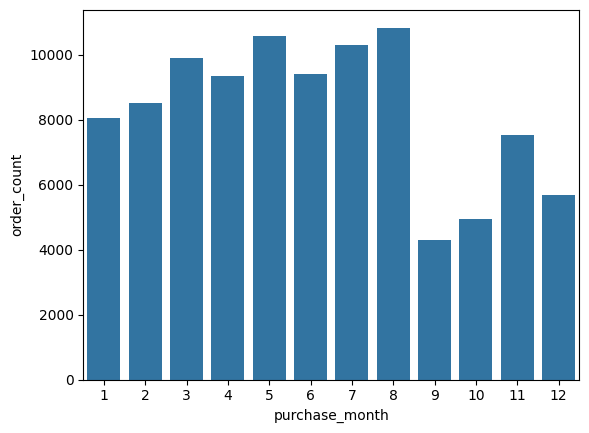

In [31]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
monthly_orders = df.groupby('purchase_month').size().reset_index(name='order_count')
highest_month = monthly_orders.loc[monthly_orders['order_count'].idxmax()]
sns.barplot(x='purchase_month', y='order_count', data=monthly_orders)

print(f"The month with the highest number of orders is month {highest_month['purchase_month']} with {highest_month['order_count']} orders.")

Which product categories generate the most orders?

In [32]:
import pandas as pd

df = pd.read_csv(f"{path}/olist_products_dataset.csv")

In [33]:
df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Product categories with the most orders:


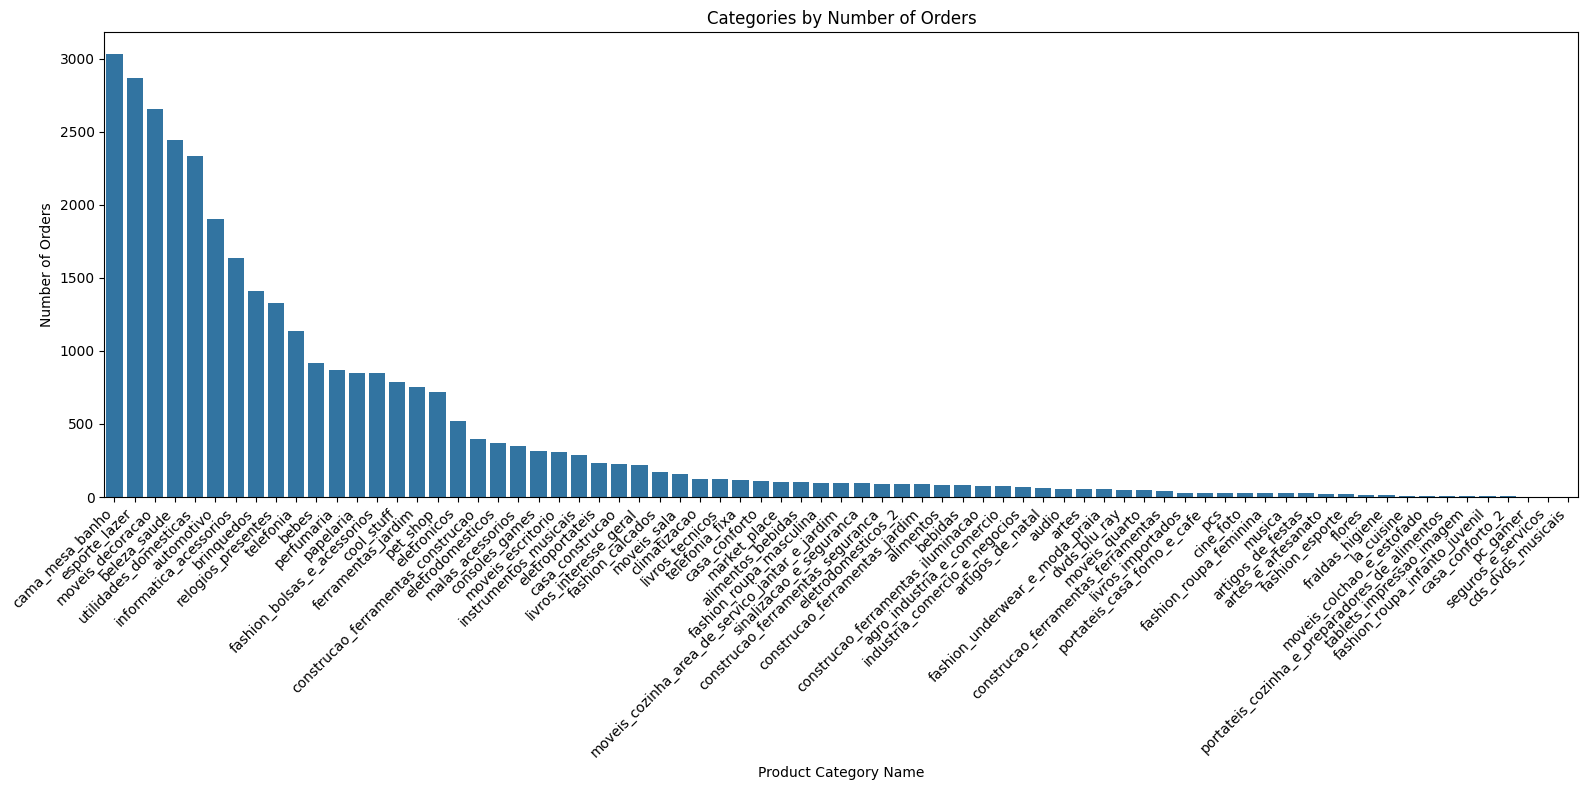

top product categories are :    product_category_name  number_of_orders
0        cama_mesa_banho              3029
1          esporte_lazer              2867
2       moveis_decoracao              2657
3           beleza_saude              2444
4  utilidades_domesticas              2335


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


print("Product categories with the most orders:")
top_categories = df['product_category_name'].value_counts().reset_index()
top_categories.columns = ['product_category_name', 'number_of_orders']
plt.figure(figsize=(16,8))
sns.barplot(x='product_category_name', y='number_of_orders', data=top_categories)
plt.title('Categories by Number of Orders')
plt.xlabel('Product Category Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("top product categories are :" ,top_categories.head())


Which product categories generate the highest revenue?

Product categories generating the highest revenue:
     product_category_name  total_revenue
11            beleza_saude     1441248.07
66      relogios_presentes     1305541.61
13         cama_mesa_banho     1241681.72
32           esporte_lazer     1156656.48
44  informatica_acessorios     1059272.40
54        moveis_decoracao      902511.79
72   utilidades_domesticas      778397.77
26              cool_stuff      719329.95
8               automotivo      685384.32
40      ferramentas_jardim      584219.21


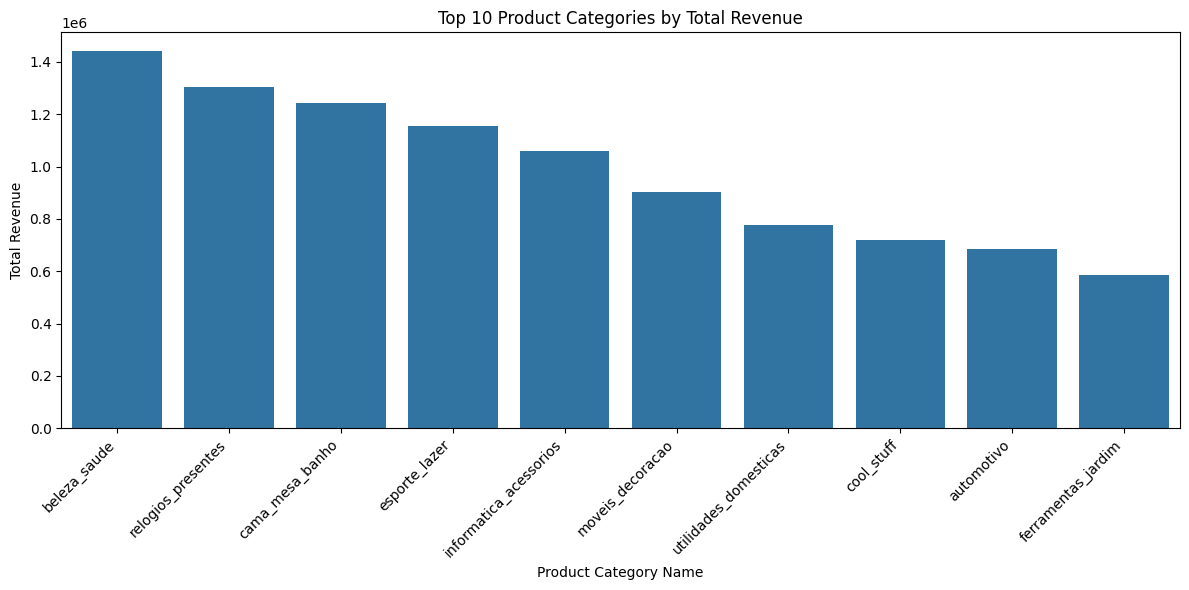

In [52]:
import pandas as pd

df = pd.read_csv(f"{path}/olist_order_items_dataset.csv")

order_items_df = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
products_df = pd.read_csv(f"{path}/olist_products_dataset.csv")

revenue_df = pd.merge(order_items_df, products_df, on='product_id', how='left')

revenue_df['total_item_revenue'] = revenue_df['price'] + revenue_df['freight_value']

category_revenue = revenue_df.groupby('product_category_name')['total_item_revenue'].sum().reset_index(name='total_revenue')

top_revenue_categories = category_revenue.sort_values(by='total_revenue', ascending=False)

print("Product categories generating the highest revenue:")
print(top_revenue_categories.head(10)) # Display top 10 categories

plt.figure(figsize=(12, 6))
sns.barplot(x='product_category_name', y='total_revenue', data=top_revenue_categories.head(10))
plt.title('Top 10 Product Categories by Total Revenue')
plt.xlabel('Product Category Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()